### Integrantes: Santiago Parada - Francisco Castro - Natalia Rodriguez - David Cifuentes

# 03 - Rol 3: Mezclas Gaussianas y Variables Latentes
**Proyecto Retador: Patrones Invisibles** - ML No Supervisado - Universidad de La Sabana · 2026-II

**Pregunta de UrbanMove:** ¿qué perfiles de movilidad existen si un viaje puede pertenecer parcialmente a varios de ellos, y qué tan seguro está el modelo de cada asignación?

**Diferencia con el Rol 2:** K-means asigna cada viaje a un solo grupo. Aquí cada viaje recibe una probabilidad de pertenencia a cada perfil, llamada responsabilidad. Un viaje que queda entre dos perfiles no se fuerza: el modelo reporta la duda, y esa duda es información operativa.

**Modelo:** se supone que cada viaje proviene de uno de K perfiles latentes (no observados). El perfil $z$ se elige con probabilidad $\pi_k$ y luego el viaje se genera de una normal multivariada propia de ese perfil:

$$p(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}(x \mid \mu_k, \Sigma_k), \qquad \sum_k \pi_k = 1$$

**Plan del bloque:**

| Sección | Contenido |
|---|---|
| 1 | Datos y variables |
| 2 | Algoritmo EM implementado paso a paso |
| 3 | Selección de K con BIC y AIC |
| 4 | Inicialización aleatoria frente a k-means++ |
| 5 | Convergencia y validación contra sklearn |
| 6 | Perfiles latentes y responsabilidades |

Datos de entrada: `muestra_50k.csv` y `etiquetas_rol2.csv`.

## 0. Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import kmeans_plusplus
SEMILLA = 42
RUTA_DATOS = '../data'

muestra = pd.read_csv(f'{RUTA_DATOS}/muestra_50k.csv', parse_dates=['pickup_datetime'])
etiquetas_r2 = pd.read_csv(f'{RUTA_DATOS}/etiquetas_rol2.csv')
muestra = muestra.merge(etiquetas_r2, on='id', how='left')
ORDEN_FRANJAS = ['madrugada', 'pico_am', 'valle', 'pico_pm', 'noche']
muestra['franja'] = pd.Categorical(muestra.franja, categories=ORDEN_FRANJAS, ordered=True)
N = len(muestra)
print(f'{N:,} viajes cargados')

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.dpi'] = 110

50,000 viajes cargados


## 1. Variables

Se usan las mismas cinco variables del Rol 2, para que los perfiles blandos de este bloque sean comparables con la partición dura del anterior: logaritmo de la distancia, logaritmo de la duración, velocidad promedio y la hora expresada como seno y coseno.

**Por qué el logaritmo importa aquí más que en K-means:** la mezcla gaussiana supone que dentro de cada perfil los datos siguen una normal. La distancia cruda tiene una cola derecha muy larga y ninguna normal la describe bien; en escala logarítmica la forma se acerca mucho más a una campana. El supuesto nunca se cumple de manera exacta y eso se señala en las limitaciones.

Matriz: 50,000 viajes × 5 variables


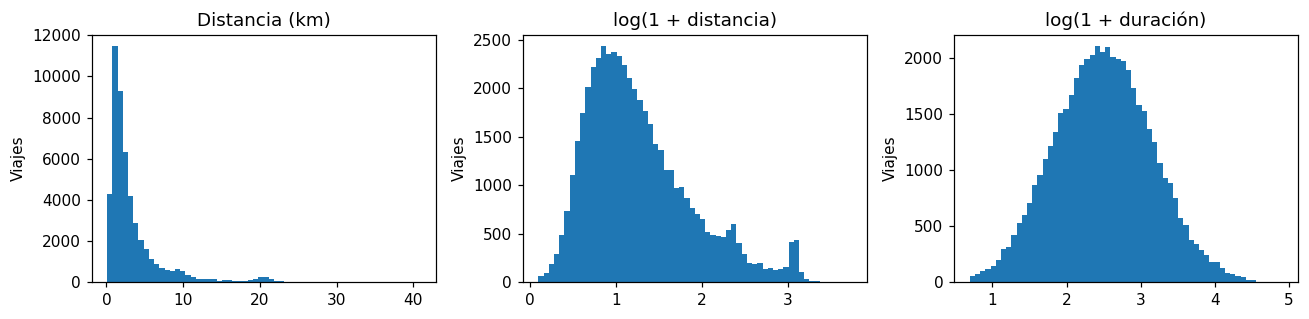

In [2]:
VARIABLES = ['log_dist', 'log_dur', 'velocidad_kmh', 'hora_sen', 'hora_cos']
muestra['log_dist'] = np.log1p(muestra.distancia_km)
muestra['log_dur'] = np.log1p(muestra.duracion_min)
muestra['hora_sen'] = np.sin(2 * np.pi * muestra.hora / 24)
muestra['hora_cos'] = np.cos(2 * np.pi * muestra.hora / 24)

escalador = StandardScaler()
X = escalador.fit_transform(muestra[VARIABLES])
n, d = X.shape
print(f'Matriz: {n:,} viajes × {d} variables')

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, (col, titulo) in zip(axes, [('distancia_km', 'Distancia (km)'),
                                    ('log_dist', 'log(1 + distancia)'),
                                    ('log_dur', 'log(1 + duración)')]):
    ax.hist(muestra[col], bins=60, color='C0')
    ax.set(title=titulo, ylabel='Viajes')
plt.tight_layout(); plt.show()

## 2. El algoritmo EM paso a paso

El problema es que no se sabe de qué perfil viene cada viaje (la variable latente $z_i$), y sin eso no se pueden estimar $\mu_k$ y $\Sigma_k$; pero sin $\mu_k$ y $\Sigma_k$ tampoco se puede saber de qué perfil viene cada viaje. EM rompe ese círculo alternando dos pasos.

**Paso E (expectation):** con los parámetros actuales, calcula la responsabilidad de cada perfil sobre cada viaje, que es la probabilidad posterior de la variable latente:

$$\gamma_{ik} = P(z_i = k \mid x_i) = \frac{\pi_k \, \mathcal{N}(x_i \mid \mu_k, \Sigma_k)}{\sum_{j=1}^{K} \pi_j \, \mathcal{N}(x_i \mid \mu_j, \Sigma_j)}$$

El denominador se calcula con log-sum-exp, exactamente la misma herramienta del Rol 1: las densidades de 50 000 viajes en cinco dimensiones producen números demasiado pequeños para representarlos directamente.

**Paso M (maximization):** con las responsabilidades fijas, actualiza los parámetros como promedios ponderados. Cada viaje aporta a los K perfiles en proporción a su responsabilidad:

$$N_k = \sum_{i=1}^{n}\gamma_{ik}, \qquad \pi_k = \frac{N_k}{n}, \qquad \mu_k = \frac{1}{N_k}\sum_i \gamma_{ik}\,x_i, \qquad \Sigma_k = \frac{1}{N_k}\sum_i \gamma_{ik}\,(x_i-\mu_k)(x_i-\mu_k)^{\top}$$

**Garantía de EM:** cada iteración completa nunca disminuye la log-verosimilitud. Esto se demuestra con la desigualdad de Jensen, la misma del Rol 1: al aplicar el logaritmo a la suma sobre perfiles se obtiene una cota inferior, y el paso M maximiza esa cota. Por eso la curva de convergencia solo puede subir o quedarse plana.

**Regularización:** a la diagonal de cada covarianza se le suma $10^{-6}$ para evitar que un perfil colapse sobre unos pocos puntos y su matriz se vuelva singular, lo que haría que la verosimilitud se dispare a infinito.

In [3]:
REG = 1e-6

def log_densidad_normal(X, mu, Sigma):
    """log N(x | mu, Sigma) para todas las filas de X. Usa Cholesky por estabilidad numérica."""
    d = X.shape[1]
    L = np.linalg.cholesky(Sigma)                      # Sigma = L L^T
    dif = np.linalg.solve(L, (X - mu).T).T             # resuelve sin invertir la matriz
    maha = np.sum(dif**2, axis=1)                      # distancia de Mahalanobis al cuadrado
    log_det = 2 * np.sum(np.log(np.diag(L)))
    return -0.5 * (d * np.log(2 * np.pi) + log_det + maha)

def paso_e(X, pesos, medias, covarianzas):
    """Devuelve las responsabilidades y la log-verosimilitud total."""
    K = len(pesos)
    log_pond = np.empty((len(X), K))
    for k in range(K):
        log_pond[:, k] = np.log(pesos[k]) + log_densidad_normal(X, medias[k], covarianzas[k])
    log_norm = logsumexp(log_pond, axis=1)             # log p(x_i): aquí actúa log-sum-exp
    responsabilidades = np.exp(log_pond - log_norm[:, None])
    return responsabilidades, log_norm.sum()

def paso_m(X, responsabilidades):
    """Actualiza pesos, medias y covarianzas como promedios ponderados."""
    n, d = X.shape
    Nk = responsabilidades.sum(axis=0)                 # peso efectivo de cada perfil
    pesos = Nk / n
    medias = (responsabilidades.T @ X) / Nk[:, None]
    covarianzas = []
    for k in range(len(Nk)):
        dif = X - medias[k]
        cov = (responsabilidades[:, k, None] * dif).T @ dif / Nk[k]
        covarianzas.append(cov + REG * np.eye(d))
    return pesos, medias, np.array(covarianzas)

In [4]:
def inicializar(X, K, modo, semilla):
    """Inicialización de los parámetros. 'kmeans++' separa los centros; 'aleatoria' toma puntos al azar."""
    rng = np.random.default_rng(semilla)
    d = X.shape[1]
    if modo == 'kmeans++':
        medias, _ = kmeans_plusplus(X, n_clusters=K, random_state=semilla)
    else:
        medias = X[rng.choice(len(X), K, replace=False)]
    pesos = np.full(K, 1 / K)
    covarianzas = np.array([np.cov(X.T) + REG * np.eye(d) for _ in range(K)])
    return pesos, medias, covarianzas

def ajustar_em(X, K, modo='kmeans++', semilla=SEMILLA, tol=1e-6, max_iter=300):
    """EM completo. Converge cuando la log-verosimilitud por viaje mejora menos que tol."""
    pesos, medias, covarianzas = inicializar(X, K, modo, semilla)
    historial, anterior = [], -np.inf
    for iteracion in range(1, max_iter + 1):
        responsabilidades, logver = paso_e(X, pesos, medias, covarianzas)
        historial.append(logver)
        if (logver - anterior) / len(X) < tol:
            break
        anterior = logver
        pesos, medias, covarianzas = paso_m(X, responsabilidades)
    return {'pesos': pesos, 'medias': medias, 'covarianzas': covarianzas,
            'responsabilidades': responsabilidades, 'logver': logver,
            'iteraciones': iteracion, 'historial': historial}

prueba = ajustar_em(X, 4)
print(f'Prueba con K = 4: {prueba["iteraciones"]} iteraciones, log-verosimilitud {prueba["logver"]:,.1f}')
print(f'¿La log-verosimilitud nunca bajó? {bool(np.all(np.diff(prueba["historial"]) >= -1e-6))}')

Prueba con K = 4: 105 iteraciones, log-verosimilitud -205,495.6
¿La log-verosimilitud nunca bajó? True


## 3. Selección de K

Al aumentar K la verosimilitud siempre mejora, así que no sirve como criterio. BIC y AIC restan una penalización por número de parámetros:

$$\text{BIC} = -2\,\ell + p\ln n, \qquad \text{AIC} = -2\,\ell + 2p$$

Con covarianzas completas, cada perfil tiene $d$ medias más $d(d+1)/2$ covarianzas, y además hay $K-1$ pesos libres, de modo que $p = K\left(d + \frac{d(d+1)}{2}\right) + K - 1$. Se busca el mínimo, y BIC penaliza más porque multiplica por $\ln n$.

Para el barrido de K se usa `GaussianMixture` de sklearn, que está optimizada en C y permite explorar muchos valores en poco tiempo. El modelo final se ajusta con la implementación propia de EM de la sección 2, y ambas se comparan en la sección 5.

In [5]:
from sklearn.mixture import GaussianMixture

def n_parametros(K, d):
    """Medias, covarianzas completas y pesos libres de una mezcla de K componentes."""
    return K * (d + d * (d + 1) / 2) + K - 1

filas = []
for K in range(2, 13):
    g = GaussianMixture(n_components=K, covariance_type='full', n_init=3,
                        reg_covar=REG, random_state=SEMILLA).fit(X)
    filas.append({'K': K, 'log-verosimilitud': g.score(X) * n, 'parámetros': int(n_parametros(K, d)),
                  'BIC': g.bic(X), 'AIC': g.aic(X)})
tabla_K = pd.DataFrame(filas).set_index('K')
tabla_K['mejora de BIC (%)'] = -100 * tabla_K.BIC.pct_change()
tabla_K

,log-verosimilitud,parámetros,BIC,AIC,mejora de BIC (%)
K,,,,,
2,"-237,503.8573",41,"475,451.3255","475,089.7146",NaN
3,"-216,989.2955",62,"434,649.4174","434,102.5911",8.5817
4,"-195,455.3193",83,"391,808.6802","391,076.6386",9.8564
5,"-172,782.0533",104,"346,689.3635","345,772.1066",11.5157
6,"-153,100.8705",125,"307,554.2132","306,451.7409",11.2882
7,"-136,090.3538",146,"273,760.3953","272,472.7077",10.9879
8,"-138,264.3682",167,"278,335.6393","276,862.7363",-1.6713
9,"-132,769.3178",188,"267,572.7538","265,914.6355",3.8669
10,"-114,261.4246",209,"230,784.1828","228,940.8492",13.7490


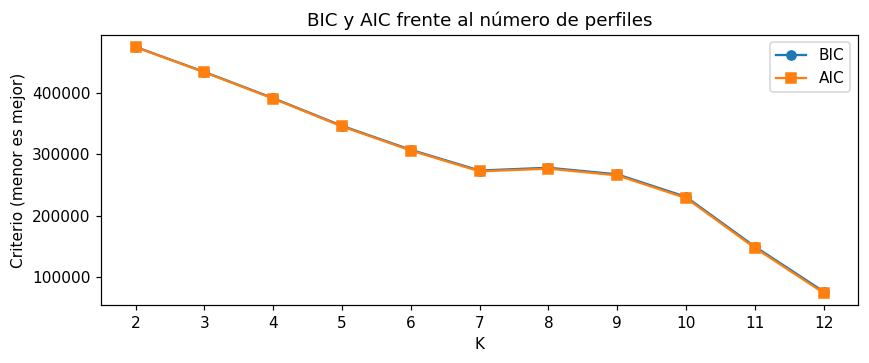

K que minimiza BIC dentro del rango: 12


In [6]:
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(tabla_K.index, tabla_K.BIC, 'o-', label='BIC')
ax.plot(tabla_K.index, tabla_K.AIC, 's-', label='AIC')
ax.set(xlabel='K', ylabel='Criterio (menor es mejor)', title='BIC y AIC frente al número de perfiles',
       xticks=tabla_K.index)
ax.legend(); plt.tight_layout(); plt.show()
print(f'K que minimiza BIC dentro del rango: {int(tabla_K.BIC.idxmin())}')

**BIC no tiene mínimo interior, y eso es un resultado en sí mismo.** Sigue bajando hasta el borde del rango, es decir, siempre vale la pena agregar componentes. La razón es que los datos no fueron generados por una mezcla finita de normales: la nube de viajes es continua y tiene colas largas, así que cada componente nueva sirve para tapar un pedazo de la forma real. La mezcla gaussiana es una aproximación útil, no el proceso verdadero.

Cuando BIC no decide, hace falta un criterio adicional. Se usa la **estabilidad**: se parte la muestra en dos mitades al azar, se ajusta un modelo independiente en cada una, se predice con ambos sobre todos los viajes y se comparan las dos asignaciones con el índice Rand ajustado. Si una estructura de K perfiles es real, dos mitades distintas deben encontrar prácticamente la misma; si K es demasiado grande, cada mitad parte la nube por donde le conviene y la coincidencia cae.

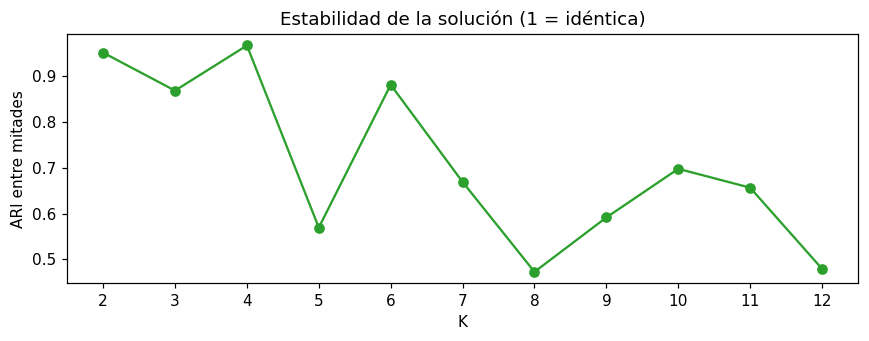

K,2,3,4,5,6,7,8,9,10,11,12
ARI entre mitades,0.9504,0.8677,0.9660,0.5693,0.8805,0.6687,0.4730,0.5915,0.6974,0.6563,0.4796


In [7]:
from sklearn.metrics import adjusted_rand_score

rng_split = np.random.default_rng(SEMILLA)
perm = rng_split.permutation(n)
mitad_a, mitad_b = perm[: n // 2], perm[n // 2 :]

estabilidad = []
for K in range(2, 13):
    ga = GaussianMixture(n_components=K, covariance_type='full', n_init=3, reg_covar=REG,
                         random_state=1).fit(X[mitad_a])
    gb = GaussianMixture(n_components=K, covariance_type='full', n_init=3, reg_covar=REG,
                         random_state=2).fit(X[mitad_b])
    estabilidad.append({'K': K, 'ARI entre mitades': adjusted_rand_score(ga.predict(X), gb.predict(X))})
estabilidad = pd.DataFrame(estabilidad).set_index('K')

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(estabilidad.index, estabilidad['ARI entre mitades'], 'o-', color='C2')
ax.set(xlabel='K', ylabel='ARI entre mitades', title='Estabilidad de la solución (1 = idéntica)',
       xticks=estabilidad.index)
plt.tight_layout(); plt.show()
estabilidad.T

**Decisión sobre K:** se elige K = 4.

BIC y AIC bajan de forma monótona, así que descartan los valores pequeños pero no señalan un óptimo. La estabilidad sí: K = 4 alcanza el ARI más alto entre mitades independientes, mientras que a partir de K = 5 la coincidencia cae de forma marcada. Además, K = 4 coincide con el número de grupos elegido por el Rol 2 con criterios distintos (codo y Davies-Bouldin), lo que permite comparar directamente la partición dura con la blanda.

## 4. Inicialización aleatoria frente a k-means++

EM converge a un óptimo local, no al global: el resultado depende de dónde empiece. Se comparan dos formas de arrancar, cada una con 10 semillas distintas.

**Aleatoria:** K viajes tomados al azar como medias iniciales. Si dos caen cerca, dos perfiles compiten por la misma región y la solución final puede ser peor.

**k-means++:** elige el primer centro al azar y cada centro siguiente con probabilidad proporcional al cuadrado de su distancia al centro más cercano ya elegido, lo que tiende a separarlos desde el inicio.

In [8]:
K_FINAL = 4
SEMILLAS = list(range(10))

filas = []
for modo in ['aleatoria', 'kmeans++']:
    for s in SEMILLAS:
        m = ajustar_em(X, K_FINAL, modo=modo, semilla=s)
        filas.append({'inicialización': modo, 'semilla': s, 'log-verosimilitud': m['logver'],
                      'iteraciones': m['iteraciones'], 'peso mínimo': m['pesos'].min()})
comparacion = pd.DataFrame(filas)

resumen_init = comparacion.groupby('inicialización').agg(
    logver_mejor=('log-verosimilitud', 'max'), logver_peor=('log-verosimilitud', 'min'),
    logver_media=('log-verosimilitud', 'mean'), desviacion=('log-verosimilitud', 'std'),
    iteraciones_media=('iteraciones', 'mean'), iteraciones_max=('iteraciones', 'max'))
display(resumen_init)

mejor_global = comparacion['log-verosimilitud'].max()
comparacion['distancia al mejor'] = mejor_global - comparacion['log-verosimilitud']
comparacion['llegó al mejor óptimo'] = comparacion['distancia al mejor'] < 1.0
display(comparacion.groupby('inicialización')['llegó al mejor óptimo'].mean().to_frame('proporción de semillas'))
comparacion.pivot(index='semilla', columns='inicialización',
                  values=['log-verosimilitud', 'iteraciones'])

,logver_mejor,logver_peor,logver_media,desviacion,iteraciones_media,iteraciones_max
inicialización,,,,,,
aleatoria,"-194,973.1999","-208,753.9414","-203,156.5392","4,498.2654",108.2000,203
kmeans++,"-194,973.1972","-207,271.7558","-201,027.7129","4,743.9446",66.0000,119


,proporción de semillas
inicialización,
aleatoria,0.1000
kmeans++,0.1000


log-verosimilitud               iteraciones         
inicialización         aleatoria      kmeans++   aleatoria kmeans++
semilla                                                            
0                  -208,753.9414 -195,260.6710    203.0000  32.0000
1                  -206,997.0709 -196,614.3071     58.0000  38.0000
2                  -203,734.2824 -203,130.5874    138.0000  64.0000
3                  -205,495.5667 -207,271.7558    102.0000 116.0000
4                  -204,702.2430 -204,150.8158    153.0000  44.0000
5                  -205,664.7538 -203,195.5266     70.0000 119.0000
6                  -204,040.1390 -204,495.9082    145.0000  98.0000
7                  -194,973.1999 -195,961.8499     54.0000  37.0000
8                  -196,121.1616 -194,973.1972     61.0000  46.0000
9                  -201,083.0332 -205,222.5102     98.0000  66.0000

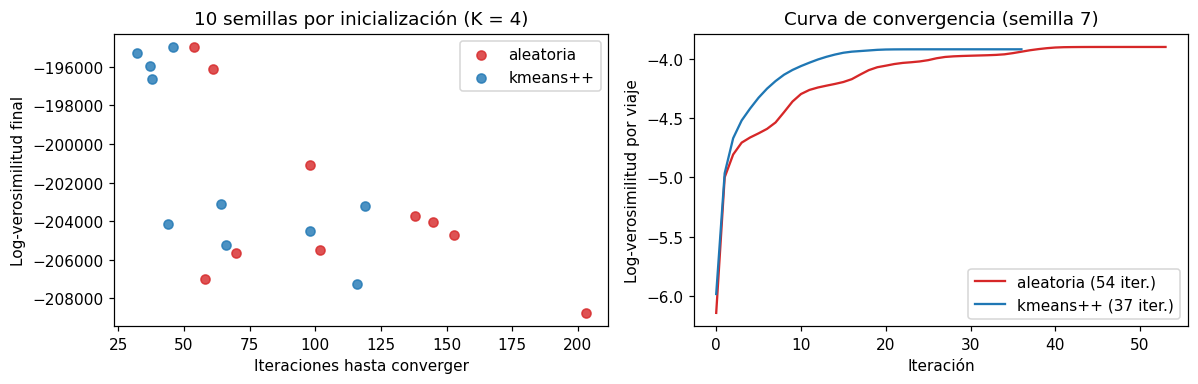

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for modo, color in [('aleatoria', 'C3'), ('kmeans++', 'C0')]:
    sub = comparacion[comparacion['inicialización'] == modo]
    axes[0].scatter(sub.iteraciones, sub['log-verosimilitud'], label=modo, color=color, alpha=0.8)
axes[0].set(xlabel='Iteraciones hasta converger', ylabel='Log-verosimilitud final',
            title=f'10 semillas por inicialización (K = {K_FINAL})')
axes[0].legend()

for modo, color in [('aleatoria', 'C3'), ('kmeans++', 'C0')]:
    m = ajustar_em(X, K_FINAL, modo=modo, semilla=7)
    axes[1].plot(np.array(m['historial']) / n, color=color, label=f'{modo} ({m["iteraciones"]} iter.)')
axes[1].set(xlabel='Iteración', ylabel='Log-verosimilitud por viaje',
            title='Curva de convergencia (semilla 7)')
axes[1].legend()
plt.tight_layout(); plt.show()

**Lectura:** con 10 semillas por método, ninguna de las dos inicializaciones es confiable por sí sola: solo 1 de cada 10 arranques llega al mejor óptimo encontrado (log-verosimilitud de -194 973). Las demás semillas se quedan en óptimos locales peores, hasta -208 754 en el caso aleatorio. La desviación entre semillas es de unos 4 500 puntos de log-verosimilitud, que es enorme frente a las diferencias entre modelos.

Donde sí hay diferencia clara es en el costo: k-means++ converge en 66 iteraciones en promedio frente a 108 de la inicialización aleatoria, y su peor resultado (-207 272) es mejor que el peor del arranque aleatorio (-208 754). También su promedio es superior (-201 028 frente a -203 157).

La curva de convergencia muestra el mismo patrón: ambas suben de forma monótona, como garantiza la desigualdad de Jensen, pero la aleatoria tarda más en la fase inicial porque empieza con medias mal separadas.

**Implicación metodológica:** el modelo final no se ajusta una sola vez. Se corren las 10 semillas con k-means++ y se conserva la de mayor log-verosimilitud, porque un único ajuste tiene el 90 % de probabilidad de quedarse en un óptimo local peor.

## 5. Convergencia y validación contra sklearn

**Criterio de parada:** se detiene cuando la log-verosimilitud por viaje mejora menos de $10^{-6}$ entre iteraciones. Se usa el valor por viaje y no el total para que el umbral no dependa del tamaño de la muestra.

**Validación:** la misma mezcla se ajusta con `sklearn.mixture.GaussianMixture` partiendo de los parámetros propios. Si la implementación es correcta, la log-verosimilitud debe coincidir en varias cifras.

Modelo final: K = 4, 46 iteraciones, log-verosimilitud = -194,973.20
sklearn.GaussianMixture: -194,973.17
Diferencia relativa: 1.30e-07
Diferencia máxima en las responsabilidades: 5.73e-03


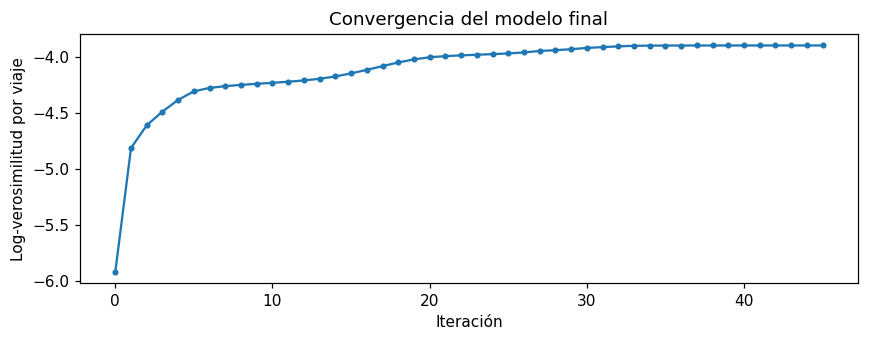

In [10]:
mejor = max((ajustar_em(X, K_FINAL, modo='kmeans++', semilla=s) for s in SEMILLAS),
            key=lambda m: m['logver'])
print(f'Modelo final: K = {K_FINAL}, {mejor["iteraciones"]} iteraciones, '
      f'log-verosimilitud = {mejor["logver"]:,.2f}')

gm = GaussianMixture(n_components=K_FINAL, covariance_type='full', reg_covar=REG,
                     means_init=mejor['medias'], weights_init=mejor['pesos'],
                     precisions_init=np.array([np.linalg.inv(c) for c in mejor['covarianzas']]),
                     max_iter=300, tol=1e-6, random_state=SEMILLA).fit(X)
logver_sklearn = gm.score(X) * n
print(f'sklearn.GaussianMixture: {logver_sklearn:,.2f}')
print(f'Diferencia relativa: {abs(logver_sklearn - mejor["logver"]) / abs(mejor["logver"]):.2e}')
print(f'Diferencia máxima en las responsabilidades: '
      f'{np.abs(gm.predict_proba(X) - mejor["responsabilidades"]).max():.2e}')

fig, ax = plt.subplots(figsize=(8, 3.2))
ax.plot(np.array(mejor['historial']) / n, 'o-', ms=3)
ax.set(xlabel='Iteración', ylabel='Log-verosimilitud por viaje', title='Convergencia del modelo final')
plt.tight_layout(); plt.show()

## 6. Perfiles latentes y responsabilidades

Los parámetros se devuelven a las unidades originales para poder leerlos como perfiles de movilidad. La responsabilidad máxima de cada viaje indica qué tan seguro está el modelo de esa asignación.

In [11]:
R = mejor['responsabilidades']
muestra['perfil'] = R.argmax(axis=1)
muestra['responsabilidad_max'] = R.max(axis=1)

medias_orig = escalador.inverse_transform(mejor['medias'])
perfiles = pd.DataFrame({
    'peso π (%)': 100 * mejor['pesos'],
    'distancia (km)': np.expm1(medias_orig[:, 0]),
    'duración (min)': np.expm1(medias_orig[:, 1]),
    'velocidad (km/h)': medias_orig[:, 2],
    'hora del perfil': (np.arctan2(medias_orig[:, 3], medias_orig[:, 4]) * 24 / (2 * np.pi)) % 24,
})
perfiles['viajes asignados'] = muestra.perfil.value_counts().sort_index()
perfiles['responsabilidad media'] = muestra.groupby('perfil').responsabilidad_max.mean()
perfiles['% fin de semana'] = 100 * muestra.groupby('perfil').fin_de_semana.mean()
perfiles['franja dominante'] = muestra.groupby('perfil').franja.agg(lambda s: s.value_counts().idxmax())
perfiles['zona origen dominante'] = muestra.groupby('perfil').zona_origen.agg(lambda s: s.value_counts().idxmax())
perfiles.index.name = 'perfil'
perfiles.to_csv(f'{RUTA_DATOS}/perfiles_rol3.csv')
perfiles

,peso π (%),distancia (km),duración (min),velocidad (km/h),hora del perfil,viajes asignados,responsabilidad media,% fin de semana,franja dominante,zona origen dominante
perfil,,,,,,,,,,
0,21.9331,2.5099,10.8570,13.9572,21.7487,11224,0.9617,27.8689,noche,2
1,24.5160,1.9198,11.5368,10.1613,10.2955,12460,0.9613,20.4896,valle,1
2,27.7130,2.0781,11.5750,10.9321,16.6974,14002,0.9762,27.2890,pico_pm,0
3,25.8379,4.1030,10.7122,22.8477,4.2303,12314,0.9521,38.9557,madrugada,6


Viajes con responsabilidad máxima menor a 0.6: 897 (1.8 %)
Viajes con responsabilidad mayor a 0.9: 44,526 (89.1 %)


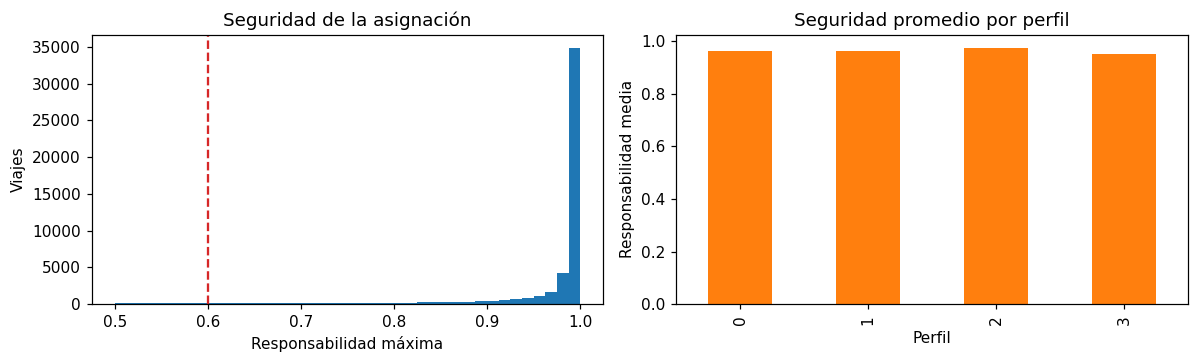

Perfil secundario de los viajes ambiguos (segunda responsabilidad más alta):


perfil secundario,0,1,2,3
perfil principal,,,,
0,0,0,2,155
1,0,0,0,224
2,5,0,0,114
3,96,174,127,0


In [12]:
# ¿Qué tan seguras son las asignaciones?
umbral = 0.6
ambiguos = muestra.responsabilidad_max < umbral
print(f'Viajes con responsabilidad máxima menor a {umbral}: {ambiguos.sum():,} ({100*ambiguos.mean():.1f} %)')
print(f'Viajes con responsabilidad mayor a 0.9: {(muestra.responsabilidad_max > 0.9).sum():,} '
      f'({100*(muestra.responsabilidad_max > 0.9).mean():.1f} %)')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(muestra.responsabilidad_max, bins=40, color='C0')
axes[0].axvline(umbral, ls='--', color='C3')
axes[0].set(xlabel='Responsabilidad máxima', ylabel='Viajes', title='Seguridad de la asignación')
muestra.groupby('perfil').responsabilidad_max.mean().plot(kind='bar', ax=axes[1], color='C1')
axes[1].set(xlabel='Perfil', ylabel='Responsabilidad media', title='Seguridad promedio por perfil')
plt.tight_layout(); plt.show()

print('Perfil secundario de los viajes ambiguos (segunda responsabilidad más alta):')
segundo = np.argsort(R, axis=1)[:, -2]
display(pd.crosstab(muestra.perfil[ambiguos], segundo[ambiguos]).rename_axis(
    index='perfil principal', columns='perfil secundario'))

In [13]:
# Comparación con la partición dura del Rol 2
comunes = muestra.dropna(subset=['cluster_km'])
ari_r2 = adjusted_rand_score(comunes.cluster_km, comunes.perfil)
print(f'Índice Rand ajustado entre los perfiles GMM y los clusters de K-means: {ari_r2:.4f}')
display(pd.crosstab(comunes.cluster_km, comunes.perfil, normalize='index').mul(100).round(1)
        .rename_axis(index='K-means (Rol 2)', columns='Perfil GMM (Rol 3)'))

print('Responsabilidad media según si el viaje fue marcado como ruido por DBSCAN:')
display(muestra.groupby('es_ruido').responsabilidad_max.agg(['mean', 'count']))

Índice Rand ajustado entre los perfiles GMM y los clusters de K-means: 0.3746


Perfil GMM (Rol 3),0,1,2,3
K-means (Rol 2),,,,
0,23.9000,5.9000,8.0000,62.2000
1,0.0000,72.9000,2.4000,24.7000
2,5.9000,16.0000,77.0000,1.1000
3,57.7000,0.0000,19.9000,22.4000


Responsabilidad media según si el viaje fue marcado como ruido por DBSCAN:


,mean,count
es_ruido,,
False,0.9628,49158
True,0.9925,842


**Lectura:** los cuatro perfiles latentes se separan sobre todo por la hora y la velocidad, no por la distancia:

| Perfil | Peso | Hora del perfil | Distancia | Velocidad | Fin de semana |
|---|---|---|---|---|---|
| 0 | 21.9 % | 21:45 | 2.5 km | 14.0 km/h | 27.9 % |
| 1 | 24.5 % | 10:18 | 1.9 km | 10.2 km/h | 20.5 % |
| 2 | 27.7 % | 16:42 | 2.1 km | 10.9 km/h | 27.3 % |
| 3 | 25.8 % | 4:14 | 4.1 km | 22.8 km/h | 39.0 % |

El perfil 3 es el más distintivo: viajes de madrugada, el doble de largos y el doble de rápidos que el resto, con el 39 % en fin de semana y origen dominante en la zona 6. Coincide con la caída de entropía que encontró el Rol 1 entre la 1:00 y las 3:00.

**Sobre las responsabilidades:** el 89.1 % de los viajes tiene una responsabilidad máxima superior a 0.9, es decir, el modelo está muy seguro de la mayoría de las asignaciones. Solo el 1.8 % queda por debajo de 0.6, y casi todos esos casos se disputan entre el perfil 3 y alguno de los demás: son los viajes de las horas frontera, cuando la madrugada se convierte en mañana.

Un detalle contraintuitivo: los viajes marcados como ruido por DBSCAN tienen una responsabilidad media más alta (0.992) que los normales (0.963). No es contradicción. DBSCAN los marca porque están en una región de baja densidad, mientras que la mezcla gaussiana los asigna con seguridad al perfil de viajes largos y rápidos, que es el único cuya campana llega hasta allá. Los dos métodos miden cosas distintas: densidad local frente a verosimilitud relativa.

**Comparación con el Rol 2:** el ARI entre la partición dura y la blanda es 0.375. Coinciden en lo esencial (el 77 % del cluster 2 de K-means cae en el perfil 2, y el 72.9 % del cluster 1 en el perfil 1) pero difieren en el criterio: K-means corta por distancia y duración, mientras que la mezcla organiza los perfiles por hora del día.

**Implicación:** UrbanMove puede operar con asignación blanda. En vez de etiquetar cada viaje, puede ponderar decisiones por la probabilidad de cada perfil, y reservar revisión manual para el 1.8 % de casos ambiguos.

## 7. Exportación

In [14]:
muestra[['id', 'perfil', 'responsabilidad_max']].to_csv(f'{RUTA_DATOS}/perfiles_viajes_rol3.csv', index=False)
resumen = pd.DataFrame([
    ('GMM', 'K seleccionado', f'{K_FINAL} perfiles (BIC monótono; máxima estabilidad entre mitades)'),
    ('EM', 'Convergencia', f'{mejor["iteraciones"]} iteraciones con tolerancia 1e-6 por viaje'),
    ('EM', 'Log-verosimilitud final', f'{mejor["logver"]:,.1f}'),
    ('EM', 'Validación contra sklearn',
     f'diferencia relativa {abs(logver_sklearn - mejor["logver"]) / abs(mejor["logver"]):.1e}'),
    ('Inicialización', 'kmeans++ vs aleatoria',
     f'{resumen_init.loc["kmeans++", "iteraciones_media"]:.1f} vs '
     f'{resumen_init.loc["aleatoria", "iteraciones_media"]:.1f} iteraciones promedio'),
    ('Responsabilidades', 'Asignaciones ambiguas', f'{100*ambiguos.mean():.1f} % con responsabilidad < 0.6'),
    ('Comparación', 'ARI con K-means del Rol 2', f'{ari_r2:.3f}'),
], columns=['Bloque', 'Medida', 'Valor'])
resumen.to_csv(f'{RUTA_DATOS}/resultados_rol3.csv', index=False)
resumen

,Bloque,Medida,Valor
0,GMM,K seleccionado,4 perfiles (BIC monótono; máxima estabilidad e...
1,EM,Convergencia,46 iteraciones con tolerancia 1e-6 por viaje
2,EM,Log-verosimilitud final,"-194,973.2"
3,EM,Validación contra sklearn,diferencia relativa 1.3e-07
4,Inicialización,kmeans++ vs aleatoria,66.0 vs 108.2 iteraciones promedio
5,Responsabilidades,Asignaciones ambiguas,1.8 % con responsabilidad < 0.6
6,Comparación,ARI con K-means del Rol 2,0.375
